In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from config import *

In [2]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.head()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_800,...,historical_top3_2100,is_historical_top3_2100,group_count_2200,winrate_2200,historical_best_2200,is_historical_best_2200,historical_top2_2200,is_historical_top2_2200,historical_top3_2200,is_historical_top3_2200
0,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1491,True,145903,g8f6,0.284366,-0.788823,-0.174046,1914.0,...,[d7d5],True,2578.0,0.447634,[d7d5],True,[d7d5],True,[d7d5],True
1,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1433,False,145903,c2c4,-0.612085,-0.807181,-0.156649,1830.0,...,[c1f4],True,2681.0,0.512495,[c1f4],True,[c1f4],True,[c1f4],True
2,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,g8f6,1491,True,33340,e7e6,0.284366,-0.066764,-0.165798,271.0,...,"[c8e6, a7a6, b7b6]",False,1064.0,0.440789,[f7f6],False,"[f7f6, h7h6]",False,"[f7f6, h7h6, g7g6]",False
3,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/8/PPP1PPPP/RN1...,e2e3,1433,False,30626,e2e3,0.206414,0.116810,-0.163842,228.0,...,"[h2h3, c2c3, f4g3]",False,998.0,0.505010,"[b1d2, c2c3, f4g3]",False,"[f4g3, b1d2]",False,"[f4g3, b1d2, c2c3]",False
4,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/4P3/PPP2PPP/RN...,c8g4,1491,True,1497,e7e6,-0.027443,2.405371,-0.102601,11.0,...,"[h7h6, b8d7, c7c6]",False,62.0,0.629032,"[a7a6, c8g4]",True,"[c8g4, a7a6]",True,"[c8g4, a7a6, f6e4]",True


## Feature Coefficients

In [3]:
coefficients = pd.DataFrame(index=FEATURES)
p_values = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = sm.add_constant(subset[FEATURES])
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=0)
    coefficients[f'elo_{elo}'] = result.params
    p_values[f'elo_{elo}'] = result.pvalues

coefficients.to_parquet("../data/coefficients.parquet")
coefficients

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200
delta,-0.006920,0.020123,-0.028166,0.030688,-0.027587,0.024357,-0.029897,0.012145,-0.003200,-0.050442,-0.025787,0.011370,-0.031171,0.067187,-0.003032
fragility_score,-0.735743,-0.706813,-0.601242,-0.556625,-0.482783,-0.525540,-0.566016,-0.564779,-0.584536,-0.488571,-0.560663,-0.547559,-0.600587,-0.557616,-0.655405
variance,0.040761,0.101716,0.017306,0.109814,0.010238,0.030613,0.085996,0.132454,0.097506,0.086164,0.124881,0.140108,0.107212,0.051397,0.011898


In [4]:
# Significance (p-value < 0.05)
p_values < 0.05

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200
delta,True,True,True,True,True,True,True,True,False,True,True,True,True,True,False
fragility_score,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
variance,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


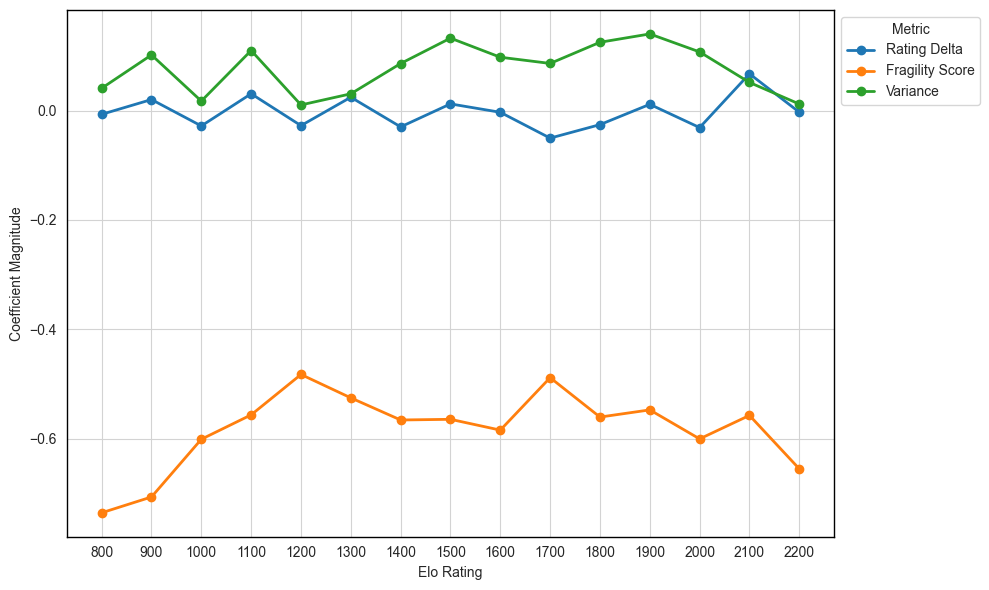

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    plt.plot(ELOS, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Coefficient Magnitude")
plt.xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_coefficients.pdf")
plt.show()

## Feature Importance

In [6]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances.to_parquet("../data/importances.parquet")
importances

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200
delta,0.128676,0.141242,0.141989,0.171576,0.150897,0.170482,0.139739,0.137887,0.143655,0.151811,0.139444,0.140267,0.148339,0.131127,0.136315
fragility_score,0.608803,0.617594,0.607709,0.563436,0.555458,0.546021,0.584892,0.565787,0.571242,0.585927,0.589108,0.592978,0.607101,0.618243,0.621190
variance,0.262521,0.241164,0.250302,0.264988,0.293644,0.283497,0.275369,0.296327,0.285103,0.262262,0.271449,0.266755,0.244560,0.250629,0.242495


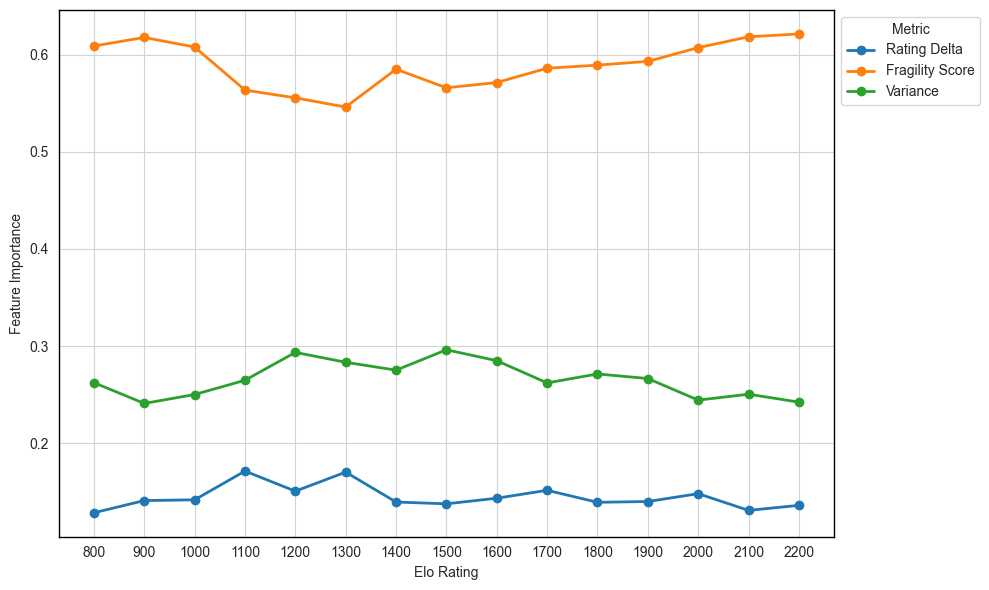

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    ax.plot(ELOS, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Feature Importance")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()